# Credit Card Fraud Detection

## Problem Statement

Credit card fraud detection is a highly imbalanced classification problem where fraudulent transactions represent only a very small portion of all transactions.

The objective of this project is to develop a machine learning model that can accurately identify fraudulent credit card transactions while minimizing incorrect classifications.

In this project:

* SMOTE is used to handle class imbalance.
* XGBoost is used as the main classification model.
* SVM is used as a baseline model.
* Decision thresholds are tuned to improve fraud detection performance.
* Feature importance scores are used to interpret the XGBoost model.
* ROC-AUC, PR-AUC, precision, recall, F1-score, and confusion matrix are used for evaluation.


In [ ]:
!pip install -q xgboost imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 284807
Columns: 31


In [ ]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print(df.isnull().sum().sum())

0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [ ]:
df = df.drop_duplicates()

print("New shape:", df.shape)

New shape: (283726, 31)


In [ ]:
print(df["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


In [ ]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


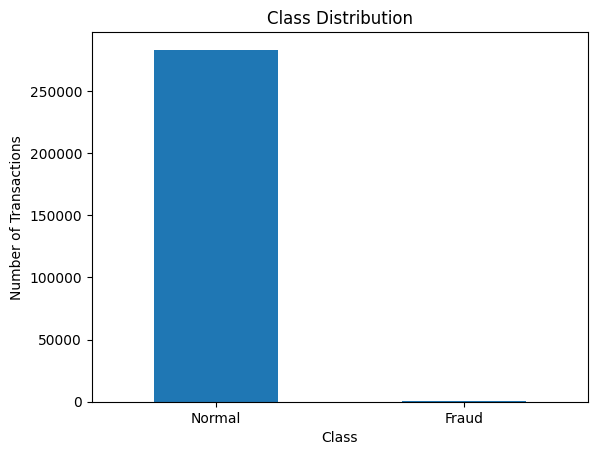

In [ ]:
df["Class"].value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution")
plt.xticks([0, 1], ["Normal", "Fraud"], rotation=0)
plt.show()

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 30)
y shape: (283726,)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [ ]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (170235, 30)
Validation: (56745, 30)
Testing: (56746, 30)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.svm import LinearSVC

# Use 30,000 samples for the SVM baseline
X_svm, _, y_svm, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=30000,
    stratify=y_train,
    random_state=42
)

print("SVM training samples:", X_svm.shape[0])

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

svm_model.fit(X_svm, y_svm)

print("SVM training completed!")

SVM training samples: 30000
SVM training completed!


In [ ]:
svm_val_score = svm_model.decision_function(X_val_scaled)

svm_val_pred = svm_model.predict(X_val_scaled)

print(classification_report(
    y_val,
    svm_val_pred,
    zero_division=0
))

svm_roc_auc = roc_auc_score(
    y_val,
    svm_val_score
)

svm_pr_auc = average_precision_score(
    y_val,
    svm_val_score
)

print("SVM ROC-AUC:", svm_roc_auc)
print("SVM PR-AUC:", svm_pr_auc)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.07      0.81      0.12        94

    accuracy                           0.98     56745
   macro avg       0.53      0.89      0.56     56745
weighted avg       1.00      0.98      0.99     56745

SVM ROC-AUC: 0.9118234941299791
SVM PR-AUC: 0.5734510520731337


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    169951
1       284
Name: count, dtype: int64

After SMOTE:
Class
0    169951
1    169951
Name: count, dtype: int64


In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost training completed!")

XGBoost training completed!


In [ ]:
xgb_val_prob = xgb_model.predict_proba(X_val_scaled)[:, 1]

xgb_test_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed!")

Predictions completed!


In [ ]:
xgb_val_pred = (xgb_val_prob >= 0.5).astype(int)

print(classification_report(
    y_val,
    xgb_val_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.66      0.80      0.72        94

    accuracy                           1.00     56745
   macro avg       0.83      0.90      0.86     56745
weighted avg       1.00      1.00      1.00     56745



In [ ]:
xgb_roc_auc = roc_auc_score(
    y_val,
    xgb_val_prob
)

xgb_pr_auc = average_precision_score(
    y_val,
    xgb_val_prob
)

print("XGBoost ROC-AUC:", xgb_roc_auc)
print("XGBoost PR-AUC:", xgb_pr_auc)

XGBoost ROC-AUC: 0.9616843067125818
XGBoost PR-AUC: 0.7894874321881613


In [ ]:
comparison = pd.DataFrame({
    "Model": ["SVM", "XGBoost"],
    "ROC-AUC": [svm_roc_auc, xgb_roc_auc],
    "PR-AUC": [svm_pr_auc, xgb_pr_auc]
})

comparison

,Model,ROC-AUC,PR-AUC
0,SVM,0.911823,0.573451
1,XGBoost,0.961684,0.789487


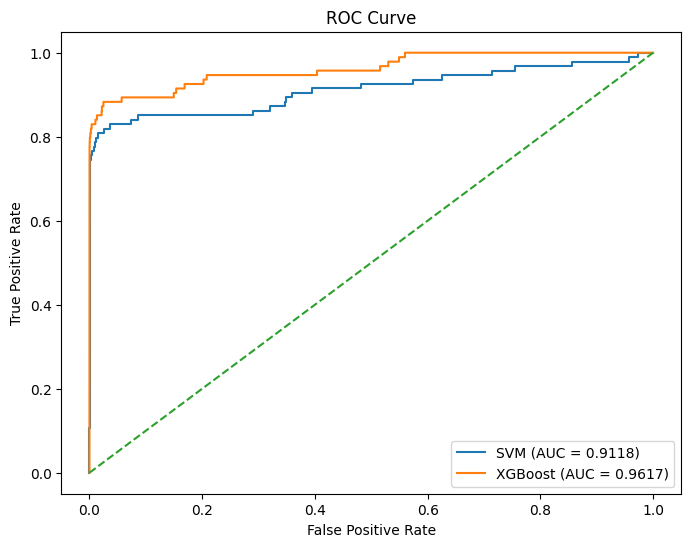

In [ ]:
from sklearn.metrics import roc_curve

svm_fpr, svm_tpr, _ = roc_curve(
    y_val,
    svm_val_score
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_val,
    xgb_val_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f"SVM (AUC = {svm_roc_auc:.4f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_roc_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

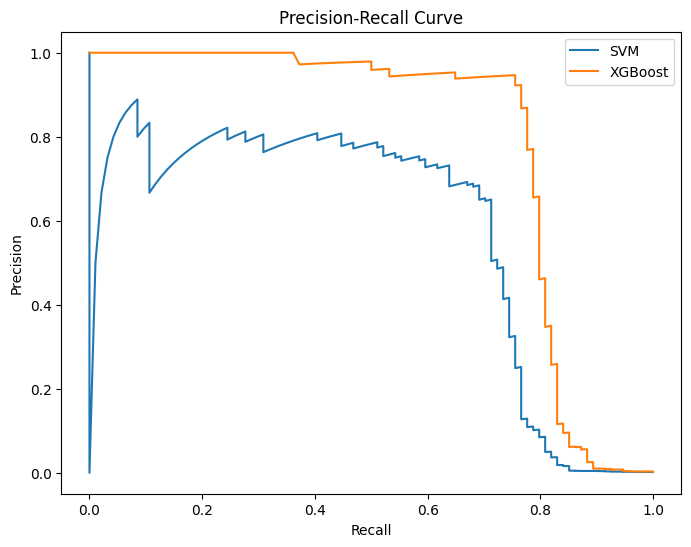

In [ ]:
from sklearn.metrics import precision_recall_curve

svm_precision, svm_recall, _ = precision_recall_curve(
    y_val,
    svm_val_score
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_val,
    xgb_val_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    svm_recall,
    svm_precision,
    label="SVM"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [ ]:
thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    pred = (xgb_val_prob >= threshold).astype(int)

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_results

,Threshold,Precision,Recall,F1
0,0.05,0.136364,0.829787,0.234234
1,0.10,0.228070,0.829787,0.357798
2,0.15,0.303150,0.819149,0.442529
3,0.20,0.374384,0.808511,0.511785
4,0.25,0.439306,0.808511,0.569288
5,0.30,0.480769,0.797872,0.600000
6,0.35,0.520833,0.797872,0.630252
7,0.40,0.547445,0.797872,0.649351
8,0.45,0.614754,0.797872,0.694444
9,0.50,0.657895,0.797872,0.721154


In [ ]:
best_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold = best_row["Threshold"]

print("Best Threshold:", best_threshold)
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1:", best_row["F1"])

Best Threshold: 0.9000000000000001
Precision: 0.9230769230769231
Recall: 0.7659574468085106
F1: 0.8372093023255814


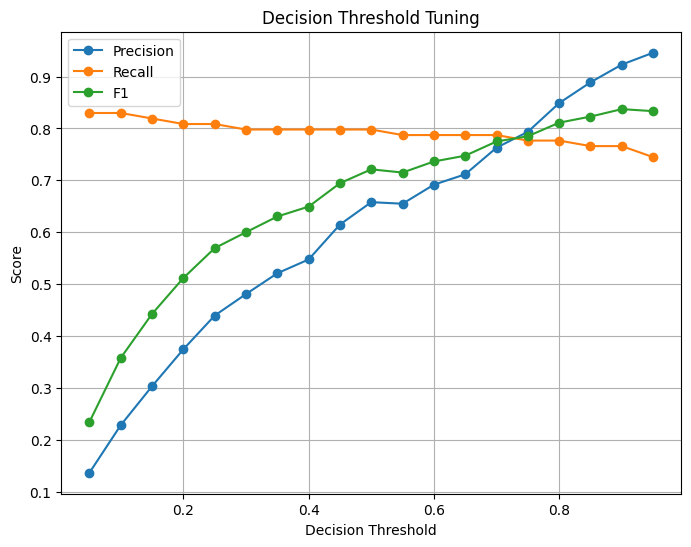

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Decision Threshold Tuning")
plt.legend()
plt.grid()

plt.show()

In [ ]:
xgb_test_pred = (
    xgb_test_prob >= best_threshold
).astype(int)

In [ ]:
print(classification_report(
    y_test,
    xgb_test_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.79      0.85        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

print(cm)

[[56645     6]
 [   20    75]]


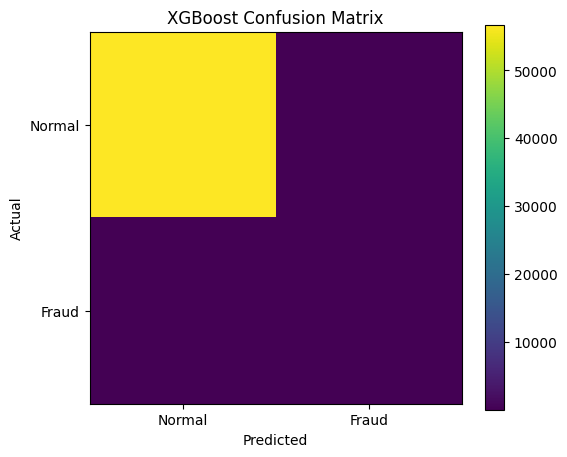

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yticks([0, 1], ["Normal", "Fraud"])

plt.colorbar()

plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 56645
False Positives: 6
False Negatives: 20
True Positives : 75


In [ ]:
default_pred = (xgb_test_prob >= 0.50).astype(int)

print("DEFAULT THRESHOLD (0.50)")
print(
    classification_report(
        y_test,
        default_pred,
        zero_division=0
    )
)

print("\nTUNED THRESHOLD")
print(
    classification_report(
        y_test,
        xgb_test_pred,
        zero_division=0
    )
)

DEFAULT THRESHOLD (0.50)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.70      0.83      0.76        95

    accuracy                           1.00     56746
   macro avg       0.85      0.92      0.88     56746
weighted avg       1.00      1.00      1.00     56746


TUNED THRESHOLD
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.79      0.85        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
14,V14,0.513556
10,V10,0.094497
12,V12,0.043438
4,V4,0.042736
8,V8,0.020426
3,V3,0.020035
9,V9,0.019205
29,Amount,0.017727
23,V23,0.016435
19,V19,0.016226


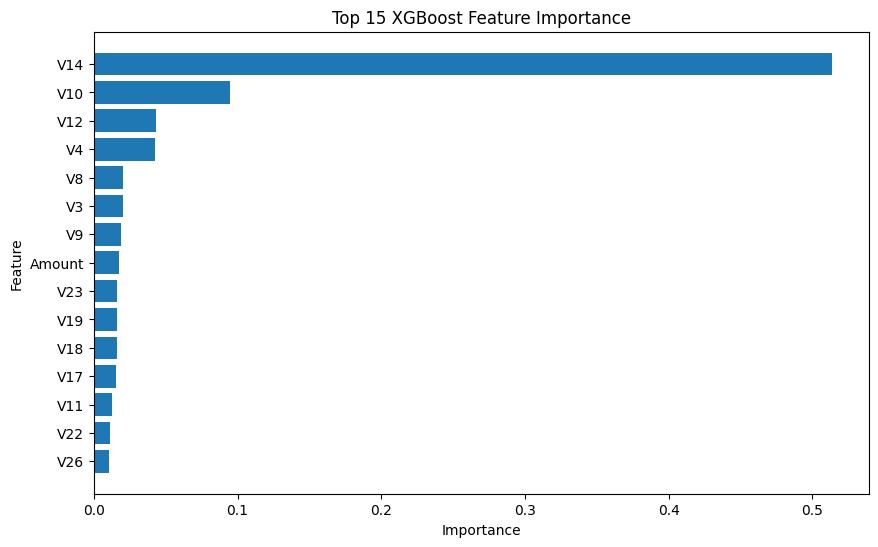

In [ ]:
top_features = importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importance")

plt.show()

In [ ]:
final_comparison = pd.DataFrame({
    "Model": ["SVM", "XGBoost"],

    "ROC-AUC": [
        svm_roc_auc,
        roc_auc_score(y_test, xgb_test_prob)
    ],

    "PR-AUC": [
        svm_pr_auc,
        average_precision_score(y_test, xgb_test_prob)
    ],

    "Precision": [
        precision_score(y_val, svm_val_pred, zero_division=0),
        precision_score(y_test, xgb_test_pred, zero_division=0)
    ],

    "Recall": [
        recall_score(y_val, svm_val_pred, zero_division=0),
        recall_score(y_test, xgb_test_pred, zero_division=0)
    ],

    "F1-Score": [
        f1_score(y_val, svm_val_pred, zero_division=0),
        f1_score(y_test, xgb_test_pred, zero_division=0)
    ]
})

final_comparison

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
0,SVM,0.911823,0.573451,0.065348,0.808511,0.120923
1,XGBoost,0.980240,0.835913,0.925926,0.789474,0.852273


# Conclusion

This project focused on detecting fraudulent credit card transactions using machine learning on a highly imbalanced dataset.

The dataset was first analyzed to understand its structure, class distribution, missing values, and duplicate records. Since fraudulent transactions represented only a very small percentage of the dataset, accuracy alone was not considered a suitable evaluation metric.

The data was divided into training, validation, and testing sets using stratified sampling. Feature scaling was then performed using the training data. An SVM model was implemented as a baseline model for comparison.

To address the severe class imbalance, SMOTE (Synthetic Minority Oversampling Technique) was applied only to the training data. XGBoost was then trained on the balanced training set and evaluated using ROC-AUC, PR-AUC, precision, recall, and F1-score.

Decision threshold tuning was performed using the validation data instead of relying only on the default 0.50 threshold. The selected threshold was then applied to the untouched test set. This helped provide a better balance between detecting fraudulent transactions and avoiding unnecessary false alarms.

A confusion matrix was also used to analyze true positives, true negatives, false positives, and false negatives. Finally, XGBoost feature importance scores were examined to identify which transaction features contributed most to the model's predictions.

Overall, the project demonstrates that handling class imbalance, selecting appropriate evaluation metrics, tuning the classification threshold, and interpreting model features are important components of an effective credit card fraud detection system. The XGBoost model provides a strong approach for this problem and can be compared with the SVM baseline using the obtained evaluation metrics.
